**Hoayu PENG / Lizandre FADE**

# AI & Big Data - Time series - Lab. 2 - Classification

This lab consists of six parts, each building upon the previous one, gradually increasing in complexity.

Deliverables:
- A .ipynb file containing your solutions.
- A PDF export of the notebook, ensuring that all cells have been executed.

For every question, please provide **short** but **informative** answers.

⚠️ Important: While you are free to use external resources, please don't rely blindly on ChatGPT - I'll find out!

Let's go!

## Part 1: Setup environment and download datasets

In [3]:
!pip install aeon
!pip install seaborn
!pip install dtw-python
!pip install tqdm
!pip install fastdtw
!pip install pycatch22

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.0/825.0 kB 39.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567862 sha256=622fc5754f707dff532970505e724c6e899489a725a89230cb64be5b100aa004
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycatch22: filename=pycatch22-0.4.5-cp312-cp312-linux_x86_64.whl size=113892 sha256=265b89a09f5ef0ec8e6ba7f23aa93b8ec31a434cf488ee4cd7c8cc00fd624625
  Stored in directory: /root/.cache/pip/wheels/89/44/33/6f846a24d9908b045e0e6b7d8a4e66adc4dec8fdf14184c90c
Success

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from aeon.datasets import load_arrow_head, load_basic_motions
from tqdm import tqdm
import pandas as pd
import time
import fastdtw
x_train_full, y_train = load_arrow_head(split='train')
x_test_full, y_test = load_arrow_head(split='test')
print(f"Arrow Head dataset of type {type(x_train_full)} and shapes, x_train: {x_train_full.shape}, y_train: {y_train.shape}, x_test: {x_test_full.shape}, y_test: {y_test.shape}")

Arrow Head dataset of type <class 'numpy.ndarray'> and shapes, x_train: (36, 1, 251), y_train: (36,), x_test: (175, 1, 251), y_test: (175,)


In [2]:
x_train, x_test = x_train_full[:, 0], x_test_full[:, 0]
print(x_train)

[[-1.9630089 -1.9578249 -1.9561449 ... -1.9053929 -1.9239049 -1.9091529]
 [-1.7745713 -1.7740359 -1.7765863 ... -1.7292269 -1.7756704 -1.7893245]
 [-1.8660211 -1.8419912 -1.8350253 ... -1.8625124 -1.8633682 -1.8464925]
 ...
 [-2.1308119 -2.1044297 -2.0747549 ... -2.0340977 -2.0800313 -2.103448 ]
 [-1.8803376 -1.8626622 -1.8496866 ... -1.8485336 -1.8640342 -1.8798851]
 [-1.80105   -1.7989155 -1.7783754 ... -1.7965491 -1.7985443 -1.80105  ]]


In [3]:
print(y_train)

['0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2'
 '0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2' '0' '1' '2']


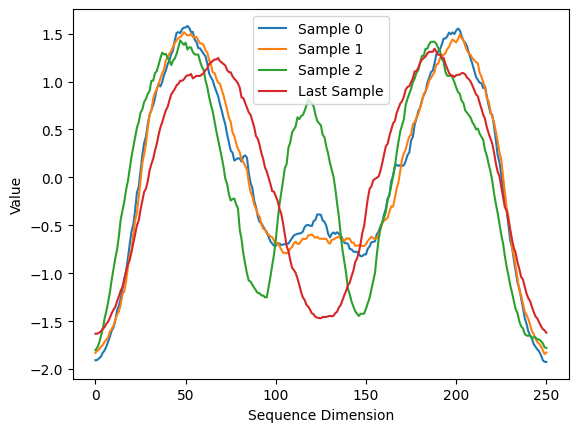

In [4]:
plt.plot(np.arange(0,len(x_test[0])),x_test[0],label='Sample 0')
plt.plot(np.arange(0,len(x_test[0])),x_test[1],label='Sample 1')
plt.plot(np.arange(0,len(x_test[0])),x_test[2],label='Sample 2')
plt.plot(np.arange(0,len(x_test[0])),x_test[-1],label='Last Sample')
plt.xlabel('Sequence Dimension')
plt.ylabel('Value')
plt.legend()
plt.show()

<StemContainer object of 3 artists>

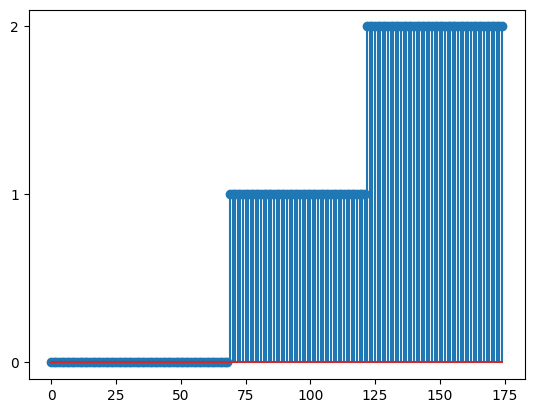

In [5]:
plt.stem(np.arange(0,len(y_test)),y_test)

**Questions:**
1. What are the dimensions of the downloaded datasets? Write their meaning and value for every subset.
2. What is the format of the labels? How many classes do we have?
3. Look into the documentation of the aeon library and write below the meaning of each class.

**Answers:**

1. The 3 dimensions are (sample id, channel, time serie). Arrow Head dataset of type <class 'numpy.ndarray'> and shapes, x_train: (36, 1, 251), y_train: (36,), x_test: (175, 1, 251), y_test: (175,)


---



Part 2: Visualizing and Understanding the Data

- Create a subplot with 3 rows and 2 columns.
- Each row should correspond to a different class in the dataset.
- Each column should distinguish between different subsets (e.g., training vs. test sets, different conditions, etc.).
- Plot all samples within each class to observe variations and patterns.

This visualization will help in understanding the structure of the dataset and how different classes are distributed.

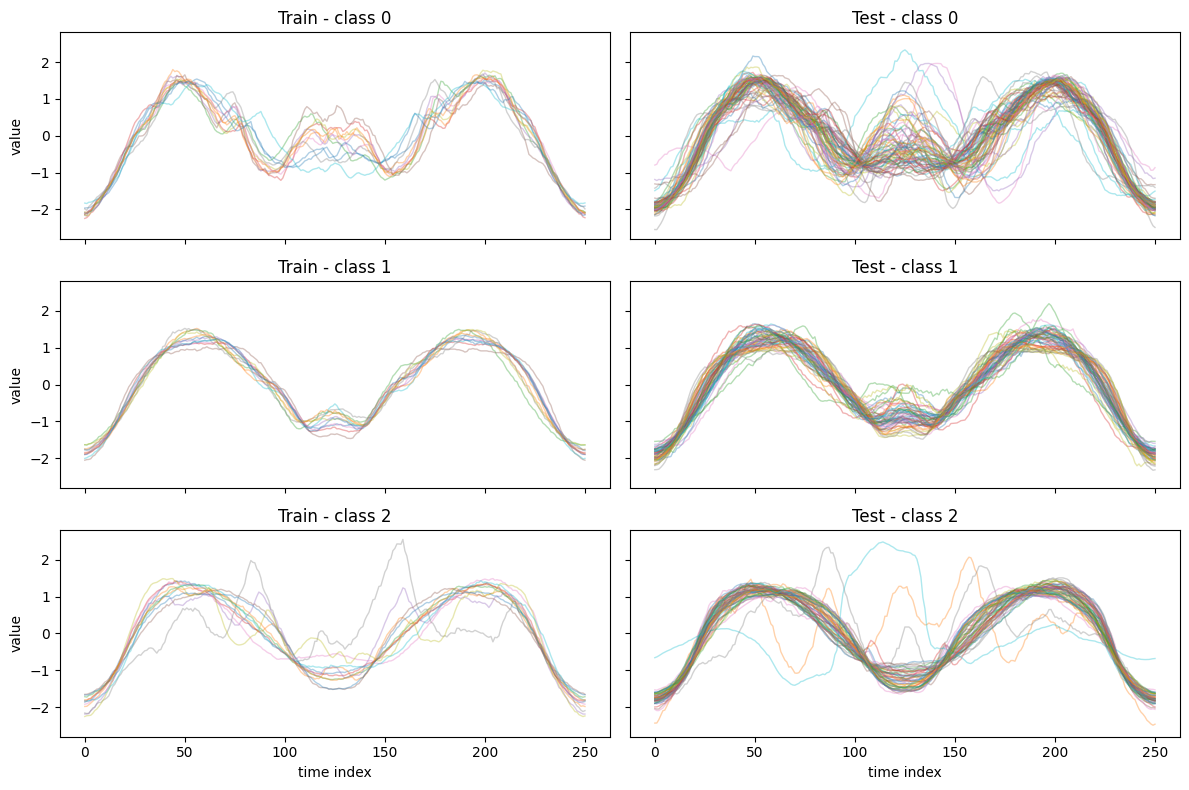

In [6]:
fig, ax = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)

classes = np.unique(np.concatenate([y_train, y_test]))  # e.g. ['0','1','2']

for i, c in enumerate(classes):
    # --- left column: TRAIN ---
    idx_tr = np.where(y_train == c)[0]
    for k in idx_tr:
        ax[i, 0].plot(x_train[k], alpha=0.35, linewidth=1)
    ax[i, 0].set_title(f"Train - class {c}")
    ax[i, 0].set_ylabel("value")

    # --- right column: TEST ---
    idx_te = np.where(y_test == c)[0]
    for k in idx_te:
        ax[i, 1].plot(x_test[k], alpha=0.35, linewidth=1)
    ax[i, 1].set_title(f"Test - class {c}")

# Common x label
ax[2, 0].set_xlabel("time index")
ax[2, 1].set_xlabel("time index")

plt.tight_layout()
plt.show()

**Questions:**

1. What do you observe? Describe the differences between the classes based on their visual patterns.
2. Do you understand the classification task? If you were the classifier, what key characteristics would you focus on to distinguish between classes?
3. Do you notice any samples that could be problematic? If so, explain why they might be challenging for classification (e.g., overlap between classes, noise, outliers).

**Answers:**

1、Class 1 is the smoothest, with a clear symmetric shape and a single deep valley in the center.
Class 0 has more variations in the middle region, with small fluctuations and less smooth transitions.
Class 2 have the largest variability, especially in the central region, where some samples present irregular peaks and deviations from the main pattern.

2、depth and position of the central valley, the smoothness of the signal, and the presence of fluctuations or irregular peaks.

3、some samples in class 2 and class 0 appear more irregular and noisy compared to others.

## Part 3: Distance-based classifiers

### Part 3.1: Implement the Euclidean and the DTW distances

In [7]:
def euclidean_distance(a, b):
  s=0
  for i in range(len(a)):
    s=s+(a[i]-b[i])**2
  return np.sqrt(s)

print(f"Euclidian distance value: {euclidean_distance(x_train[0], x_train[1])}")

Euclidian distance value: 5.466689798005681


In [8]:
def dtw(a, b, window=100):
    dtw_matrix = -np.ones((len(a), len(b)))
    for i in range(len(a)):
      for j in range(max(0, i - window), min(len(b), i + window)):
        dtw_matrix[i, j] = np.sqrt((a[i]-b[j])**2) #+(i-j)**2 is supposed to be null!!
         #the issue is that the window must be centred on windows//2 so the value at the sides willl be cut
    #a,b first value and last value must be used for first and last dtw_matrix values
    dtw_matrix[0,0]=abs(a[0]-b[0])
    dtw_matrix[-1,-1]=abs(a[-1]-b[-1])
    return dtw_matrix
distance_matrix = dtw(x_train[0], x_train[-1], window=100)
print(f"DTW distance value: {distance_matrix}")

DTW distance value: [[ 0.1619589  0.1640934  0.1846335 ... -1.        -1.        -1.       ]
 [ 0.1567749  0.1589094  0.1794495 ... -1.        -1.        -1.       ]
 [ 0.1550949  0.1572294  0.1777695 ... -1.        -1.        -1.       ]
 ...
 [-1.        -1.        -1.        ...  0.1088438  0.1068486  0.1043429]
 [-1.        -1.        -1.        ...  0.1273558  0.1253606  0.1228549]
 [-1.        -1.        -1.        ...  0.1126038  0.1106086  0.1081029]]


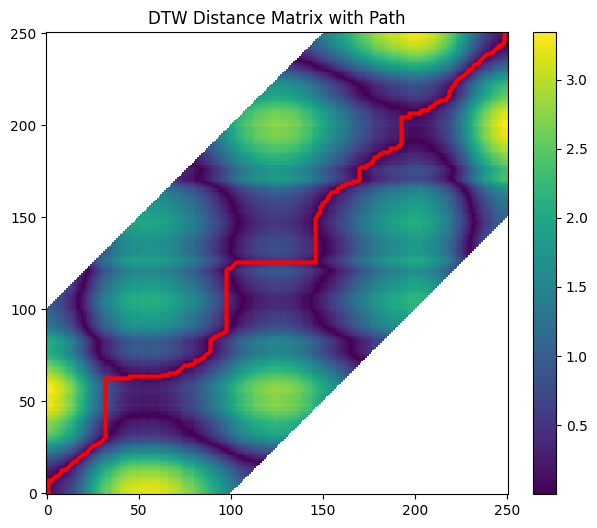

(0, 0)


In [12]:
def min_cost_path(matrix):
    i, j = matrix.shape[0] - 1, matrix.shape[1] - 1
    path = [(i, j)]

    while i > 0 or j > 0:
        neighbors = []

        # haut
        if i > 0 and matrix[i-1, j] != -1:
            neighbors.append((matrix[i-1, j], i-1, j))

        # gauche
        if j > 0 and matrix[i, j-1] != -1:
            neighbors.append((matrix[i, j-1], i, j-1))

        # diagonale
        if i > 0 and j > 0 and matrix[i-1, j-1] != -1:
            neighbors.append((matrix[i-1, j-1], i-1, j-1))

        # sécurité : si aucun voisin valide → on casse
        if not neighbors:
            break

        _, i, j = min(neighbors)
        path.append((i, j))
    path.append((0,0))
    return path[::-1]


def visualize_distance_matrix(matrix,visible=False):
  path = min_cost_path(matrix)
  if(visible==True):
    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.cm.viridis
    cmap.set_bad(color='white')
    masked_matrix = np.ma.masked_where(matrix == -1, matrix)
    im = ax.imshow(masked_matrix, interpolation='nearest', cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    path_x, path_y = zip(*path)
    ax.plot(np.array(path_y) + 0.5, np.array(path_x) + 0.5, marker="o", color="red", markersize=2)

    ax.invert_yaxis()
    plt.title("DTW Distance Matrix with Path")
    plt.show()
  return path
print(visualize_distance_matrix(distance_matrix,True)[0])

In [13]:
def dtw_distance(a, b, window=100):
  # TODOD: Wrapper that returns the final distance
    path=visualize_distance_matrix(dtw(x_train[0], x_train[-1], window))
    s=0
    for el in path:
        s= (a[el[0]]-b[el[1]])**2+s
    return np.sqrt(s)

print("dtw_distance : " + str(dtw_distance(x_test[0],x_test[-50])))
def my_fastdtw(a, b):
    return fastdtw.fastdtw(a, b, radius=20)[0]

dtw_distance : 9.89530959804132


Run a random example between two time series and answer the questions below.

**Questions:**
1. Does your implementation match the Euclidean distance when window = 1 ? Why or why not?
2. What do you observe as you change the window size? How does it affect the DTW alignment?
3. Up to which value does the window size affect the result? Justify your answer.

**Answers:**
1. The implementation doesn't match the Euclidean distance for window=1 (0.3043152) (and above). It's thank to the distance matrix that select the lowest value at each iteration (if it could choose only one value, it would obviously be like the euclidean distance).
2. The wider the window the less aligned is the DTW because it finds new values more optimized. At a certain window though the DTW stays the same.
3. The difference between window=100 and window =1 is none whetver the sample compared. Because the optimization is small and the number of values even everything out.

### Part 3.2: Implement the kNN classifier

In [14]:

def knn_classifier_single(x_train, y_train, x_test, distance_function, k=5):
  # TODO
    distances = []
    for i in range(len(x_train)):
        d = distance_function(x_test, x_train[i])
        distances.append((d, y_train[i])) # store (distance, label)

    distances.sort(key=lambda x: x[0])

    # Find the k min distances
    nearest_neighbors = distances[:k]


    # Return their voted most label
    votes={'1':0,'2':0,'0':0}
    for j in range(len(nearest_neighbors)):
        if(nearest_neighbors[j][1]=='0'):
            votes['0']=votes['0']+1
        if(nearest_neighbors[j][1]=='1'):
            votes['1']=votes['1']+1
        if(nearest_neighbors[j][1]=='2'):
            votes['2']=votes['2']+1


    prediction = max(votes, key=votes.get)
    return prediction

ed_tic = time.time()
knn_classifier_single(x_train, y_train, x_test[0], euclidean_distance, k=5)
ed_toc = time.time()

dtw_tic = time.time()
knn_classifier_single(x_train, y_train, x_test[0], dtw_distance, k=5)
dtw_toc = time.time()

fast_dtw_tic = time.time()
knn_classifier_single(x_train, y_train, x_test[0], my_fastdtw, k=5)
fast_dtw_toc = time.time()

print(f"ED distance time: {(ed_toc - ed_tic):.4f} secs")
print(f"DTW distance time: {(dtw_toc - dtw_tic):.4f} secs")
print(f"Fast DTW distance time: {(fast_dtw_toc - fast_dtw_tic):.4f} secs")

ED distance time: 0.0050 secs
DTW distance time: 2.3494 secs
Fast DTW distance time: 0.0359 secs


For window = 40 ->6.3s / For window= 100 ->7.89s

In [15]:
def knn_classifier(x_train, y_train, x_test, distance_function, k=5):
    predictions = []
    for i in range(len(x_test)):
        pred_i = knn_classifier_single(x_train, y_train, x_test[i], distance_function, k=k)
        predictions.append(pred_i)
    return np.array(predictions)

# Example
preds = knn_classifier(x_train, y_train, x_test, euclidean_distance, k=22)
preds[:10]

array(['0', '1', '0', '0', '0', '1', '1', '1', '0', '1'], dtype='<U1')

In [16]:
import numpy as np

def accuracy(y_pred, y_true):
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    return np.mean(y_pred == y_true)

print("Accuracy (ED, k=22):", accuracy(preds, y_test))

Accuracy (ED, k=22): 0.5085714285714286


In [17]:
knn_classifier_single(x_train, y_train, x_test[0], euclidean_distance, k=5)

'2'

In [18]:
ed_trials = []
for k in tqdm(range(1, 20)):  # k=1..19
    preds_k = knn_classifier(x_train, y_train, x_test, euclidean_distance, k=k)
    acc_k = accuracy(preds_k, y_test)
    ed_trials.append({"k": k, "acc": acc_k})

ed_trials_df = pd.DataFrame(ed_trials)
ed_trials_df



100%|██████████| 19/19 [00:16<00:00,  1.18it/s]


,k,acc
0,1,0.800000
1,2,0.714286
2,3,0.788571
3,4,0.622857
4,5,0.640000
5,6,0.617143
6,7,0.628571
7,8,0.582857
8,9,0.600000
9,10,0.548571


In [ ]:
# find best k
best_row = ed_trials_df.loc[ed_trials_df["acc"].idxmax()]
best_k = int(best_row["k"])

print("Best k found:", best_k)
print("Best accuracy:", float(best_row["acc"]))

In [ ]:
def dtw_distance_noplot(a, b, window=100):
    n, m = len(a), len(b)
    w = max(window, abs(n - m))

    INF = 1e18
    D = np.full((n + 1, m + 1), INF, dtype=float)
    D[0, 0] = 0.0

    for i in range(1, n + 1):
        j_start = max(1, i - w)
        j_end = min(m, i + w)
        for j in range(j_start, j_end + 1):
            cost = (a[i - 1] - b[j - 1]) ** 2
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    return float(np.sqrt(D[n, m]))

print("best_k =", best_k)

# --- DTW trials (test different windows) ---
dtw_trials = []

for w in tqdm([5,10,20]):

    def dtw_w(a, b):
        return dtw_distance_noplot(a, b, window=w)

    preds_w = knn_classifier(x_train, y_train, x_test, dtw_w, k=best_k)
    acc_w = accuracy(preds_w, y_test)

    dtw_trials.append({"window": w, "k": best_k, "acc": acc_w})

dtw_trials_df = pd.DataFrame(dtw_trials)
dtw_trials_df

In [ ]:
# preds = knn_classifier(x_train, y_train, x_test, my_fastdtw, 7)

dtw_trials = []
for k in tqdm(range(1, 20, 2)):
    # TODO: Use best k from above and test for multiple windows
    # TODO: Save results in list of dictionaries


    for w in [1, 5, 10, 20]:
        def fastdtw_w(a, b):
            return fastdtw.fastdtw(a, b, radius=w)[0]

        preds_w = knn_classifier(x_train, y_train, x_test, fastdtw_w, k=k)
        acc_w = accuracy(preds_w, y_test)

        dtw_trials.append({
            "k": k,
            "window": w,
            "acc": acc_w
        })

dtw_trials_df = pd.DataFrame(dtw_trials)
dtw_trials_df


In [ ]:
ed_trials_df  = pd.DataFrame(ed_trials)
dtw_trials_df = pd.DataFrame(dtw_trials)


display(ed_trials_df.head())
display(dtw_trials_df.head())

import matplotlib.pyplot as plt

# --- Draw only one graph: how acc changes with k for each window ---
plt.figure(figsize=(7, 4))

for w in sorted(dtw_trials_df["window"].unique()):
    tmp = dtw_trials_df[dtw_trials_df["window"] == w].sort_values("k")
    plt.plot(tmp["k"], tmp["acc"], marker="o", label=f"window={w}")

plt.xlabel("k")
plt.ylabel("accuracy")
plt.title("FastDTW kNN: accuracy vs k for different windows")
plt.grid(True)
plt.legend()
plt.show()


**Questions:**
1. What is the best value for k and the window size? How do they impact the classification performance?

2. Which distance measure should we use? Justify your choice based on the dataset and DTW behavior.

3. What do you think about the results?

1、The best value of k is 1, because it gives the highest accuracy (0.8 with Euclidean distance and about 0.79 with DTW).The best window size is 5, because it gives better accuracy than larger windows. A small window can give better accuracy and faster computation, but a large window is slower and does not improve performance.

2、DTW， because it can align time series even if they are shifted in time.

3、These results show that in a small k values, kNN works good.The best performance is obtained with k = 1 and a small window.Accuracy decreases when k becomes larger. DTW and FastDTW are more suitable than Euclidean distance for time series classification.

## Part 4: Feature-based classifiers

### Part 4.1: Feature extraction

1. Extract features from the time series data using the Catch22 library. Ensure that each sample is transformed into a feature vector.
2. Convert the extracted features from NumPy arrays to Torch tensors, preparing them for use in a PyTorch model. Don't forget the labels too.

In [ ]:
import numpy as np
import torch
import pycatch22

def catch22_transform(X):
    feats = []
    for i in range(len(X)):
        ts = np.asarray(X[i], dtype=float).ravel()
        out = pycatch22.catch22_all(ts)           # dict-like output
        feats.append(out["values"])               # 22 features
    return np.asarray(feats, dtype=np.float32)

# 1) extract features
X_train_feat = catch22_transform(x_train)
X_test_feat  = catch22_transform(x_test)

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat shape :", X_test_feat.shape)

# 2) convert to torch tensors (features + labels)
X_train_t = torch.tensor(X_train_feat, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_feat, dtype=torch.float32)

# labels: keep as int64 for classification
# if labels are strings like '0','1','2', convert them:
y_train_np = np.asarray(y_train)
y_test_np  = np.asarray(y_test)

if y_train_np.dtype.kind in {"U", "S", "O"}:
    classes = np.unique(np.concatenate([y_train_np, y_test_np]))
    cls2id = {c: i for i, c in enumerate(classes)}
    y_train_np = np.array([cls2id[c] for c in y_train_np], dtype=np.int64)
    y_test_np  = np.array([cls2id[c] for c in y_test_np], dtype=np.int64)

y_train_t = torch.tensor(y_train_np, dtype=torch.long)
y_test_t  = torch.tensor(y_test_np, dtype=torch.long)

print("y_train_t shape:", y_train_t.shape, "classes:", torch.unique(y_train_t))


### Part 4.2: Setup the training pipeline with Torch

1. Define a simple linear model using PyTorch's nn.Linear. Ensure it takes the extracted feature vectors as input and outputs class probabilities.
2. Choose a loss function and an optimizer, such as Cross-Entropy Loss and Adam/SGD.
3. Implement the training loop, including forward pass, loss computation, backpropagation, and parameter updates. Train the model for a reasonable number of epochs.
4. Evaluate the model on the test set and report relevant metrics (e.g., accuracy, precision, recall).

i did some code before demo code.

In [20]:
import torch
import torch.nn as nn

input_dim = X_train_feat.shape[1]   # 22 features
num_classes = len(torch.unique(y_train_t))

model = nn.Sequential(
    nn.Linear(input_dim, num_classes)
)

print(model)


NameError: name 'X_train_feat' is not defined

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
from tqdm import tqdm

num_epochs = 1000
batch_size = 16
dataset_size = X_train_t.shape[0]

history = []

for epoch in tqdm(range(num_epochs), desc="Training"):
    permutation = torch.randperm(dataset_size)

    epoch_loss = 0.0
    correct = 0
    total = 0

    for i in range(0, dataset_size, batch_size):
        indexes = permutation[i:i+batch_size]

        curr_x = X_train_t[indexes]
        curr_y = y_train_t[indexes]

        # Forward
        outputs = model(curr_x)
        loss = loss_fn(outputs, curr_y)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Accuracy (train)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == curr_y).sum().item()
        total += curr_y.size(0)

    acc = correct / total

    history.append({
        "epoch": epoch,
        "loss": epoch_loss,
        "accuracy": acc
    })


In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, pred = torch.max(outputs, 1)
    test_acc = (pred == y_test_t).float().mean().item()

print(f"MLP accuracy on test set: {test_acc:.4f}")


In [ ]:
df = pd.DataFrame(history)

plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["loss"], label="loss")
plt.plot(df["epoch"], df["accuracy"], label="train acc")
plt.xlabel("epoch")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
results = []

# Hyperparameter combinations
learning_rates = [0.001, 0.01]
epochs_list = [100, 200]
hidden_sizes = [32, 64]
batch_sizes = [16]
activations = {
    "ReLU": nn.ReLU()
}

input_dim = X_train_feat.shape[1]
num_classes = len(torch.unique(y_train_t))


# -------- Linear model --------
for lr in learning_rates:
    for num_epochs in epochs_list:
        for batch_size in batch_sizes:

            model = nn.Sequential(
                nn.Linear(input_dim, num_classes)
            )

            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            dataset_size = X_train_t.shape[0]

            # Training
            for epoch in range(num_epochs):

                permutation = torch.randperm(dataset_size)

                for i in range(0, dataset_size, batch_size):

                    indexes = permutation[i:i+batch_size]

                    curr_x = X_train_t[indexes]
                    curr_y = y_train_t[indexes]

                    outputs = model(curr_x)
                    loss = loss_fn(outputs, curr_y)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # Evaluation
            model.eval()
            with torch.no_grad():

                outputs = model(X_test_t)
                _, predicted = torch.max(outputs, 1)

                acc = (predicted == y_test_t).float().mean().item()

            results.append({
                "model": "Linear",
                "hidden": 0,
                "activation": "None",
                "batch_size": batch_size,
                "lr": lr,
                "epochs": num_epochs,
                "accuracy": round(acc, 3)
            })


# -------- MLP model (1 hidden layer) --------
for lr in learning_rates:
    for num_epochs in epochs_list:
        for hidden in hidden_sizes:
            for batch_size in batch_sizes:
                for act_name, act_fn in activations.items():

                    model = nn.Sequential(
                        nn.Linear(input_dim, hidden),
                        act_fn,
                        nn.Linear(hidden, num_classes)
                    )

                    loss_fn = nn.CrossEntropyLoss()
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                    dataset_size = X_train_t.shape[0]

                    # Training
                    for epoch in range(num_epochs):

                        permutation = torch.randperm(dataset_size)

                        for i in range(0, dataset_size, batch_size):

                            indexes = permutation[i:i+batch_size]

                            curr_x = X_train_t[indexes]
                            curr_y = y_train_t[indexes]

                            outputs = model(curr_x)
                            loss = loss_fn(outputs, curr_y)

                            optimizer.zero_grad()
                            loss.backward()
                            optimizer.step()

                    # Evaluation
                    model.eval()

                    with torch.no_grad():

                        outputs = model(X_test_t)
                        _, predicted = torch.max(outputs, 1)

                        acc = (predicted == y_test_t).float().mean().item()

                    results.append({
                        "model": "MLP",
                        "hidden": hidden,
                        "activation": act_name,
                        "batch_size": batch_size,
                        "lr": lr,
                        "epochs": num_epochs,
                        "accuracy": round(acc, 3)
                    })


# Convert to dataframe
results_df = pd.DataFrame(results)

# Sort by best accuracy
results_df = results_df.sort_values("accuracy", ascending=False)

results_df




In [ ]:
print("Best configuration:")
print(results_df.iloc[0])


Questions:
1. Experiment with different hyperparameters (n_layers, neurons per layer, activation functions, n_epochs, batch_size, etc.). What is the best combination of hyperparameters you found? Justify your choice.
2. Compare the results of the feature-based approach with the previous approach. Are the results better? Why do you think this is the case, considering the data?

1、We tested different hyperparameters.The best configuration is:Model: Linear

Learning rate: 0.01，Epochs: 200，Batch size: 16，Accuracy: 0.611.
A higher learning rate (0.01) helped the model learn faster.Using 200 epochs showing better performance than 100 epochs.More complex models(MLP) did not improve the accuracy.

2、The feature-based approach achieved an accuracy of about 0.61.

This is lower than the DTW-based classifier, which achieved higher accuracy.

DTW works directly on the time series shape, while Catch22 extracts only 22 features.
Some important temporal information may be lost.So, we can say DTW is more suitable for this dataset.

---------------------------------------------------

## Part 5: Raw-based classifiers

In this section, we will train a classifier directly on the raw time series data.
1. Prepare the dataset in its raw form (without feature extraction).
2. Define a small 1D Convolutional Neural Network (1D-CNN) architecture for classification.
3. Implement the training pipeline, including:
  * Loss function and optimizer selection
  * Training loop
  * Model evaluation

In [21]:
input_length = len(x_train[0])

model = nn.Sequential(
    nn.Conv1d( in_channels=1, out_channels=16, kernel_size=30, padding=30 // 2 ),
    #kernel_size corresponds to the size of the pattern to be tested
    #padding is to add 0 (by default) to the signal to test the pattern at the end and beginning
    nn.ReLU(),
    #Helps to add non-linearity
    nn.MaxPool1d(kernel_size=2),
    #Divise the length by taking the highest value
    nn.Flatten(), # Added Flatten layer here
    nn.Linear(16 * 126, 3)
    #16 * 126 is the correct number of inputs after Conv1d and MaxPool1d
)

In [22]:
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)

y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int) #nn.CrossEntropyLoss needs a int type

y_train_tensor = torch.tensor(y_train_int, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_int, dtype=torch.long)

In [23]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

num_epochs = 1000
batch_size = 16
dataset_size = y_train_tensor.shape[0]

cnn_history = []
pbar = tqdm(range(num_epochs), desc='Training', leave=True)

for n in pbar:
    curr_indexes = torch.randint(0, dataset_size, (batch_size,))
    curr_x = X_train_tensor[curr_indexes].unsqueeze(1)
    curr_y = y_train_tensor[curr_indexes]
    y_pred = model(curr_x)

    #Loss
    loss = loss_fn(y_pred, curr_y)

    #Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Accuracy
    predicted_classes = torch.argmax(y_pred, dim=1)
    acc = (predicted_classes == curr_y).float().mean().item()

    cnn_history.append({
        'epoch': n,
        'loss': loss.item(),
        'accuracy': acc
    })
    pbar.set_description(f"Training loss {loss.item():.4f}, Training accuracy: {acc:.4f}")
    pbar.refresh()


Training loss 0.2652, Training accuracy: 0.9375: 100%|██████████| 1000/1000 [00:08<00:00, 114.82it/s]


In [24]:
# Evaluate the model on the test set
correct_predictions = 0

# Prepare the test tensor to have the correct shape for Conv1d: (batch_size, channels, length)
X_test_tensor_reshaped = X_test_tensor.unsqueeze(1) # Adds a channel dimension

# Process the entire test set as a batch
with torch.no_grad(): # Disable gradient calculations for evaluation
    test_outputs = model(X_test_tensor_reshaped)
    predicted_classes = torch.argmax(test_outputs, dim=1)
    correct_predictions = (predicted_classes == y_test_tensor).sum().item()

accuracy = correct_predictions / len(y_test_tensor)
print(f"CNNs accuracy: {accuracy}")

CNNs accuracy: 0.6571428571428571


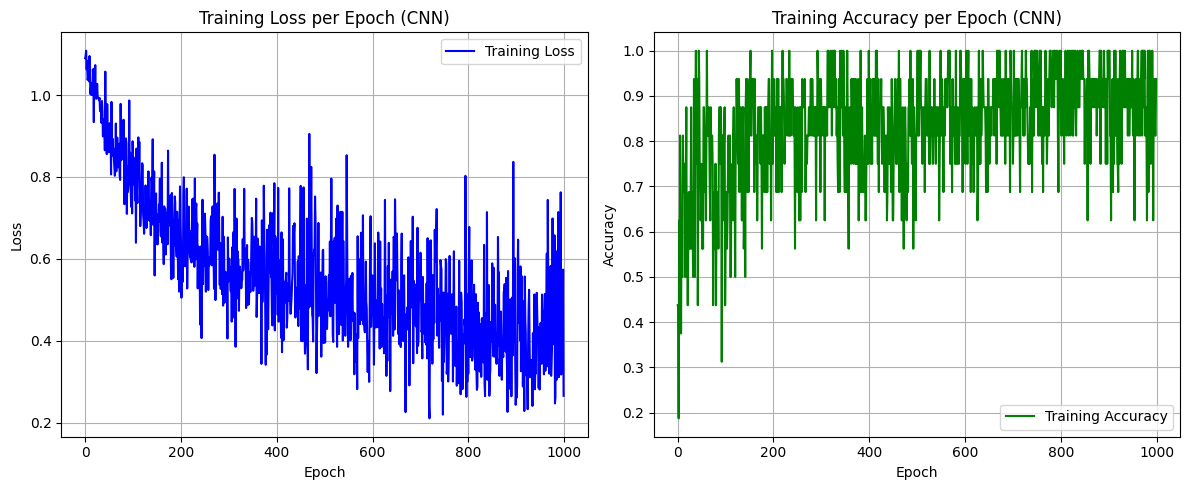

In [25]:
df = pd.DataFrame(cnn_history)

plt.figure(figsize=(12, 5))

# --- Courbe de Loss ---
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['loss'], label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch (CNN)')
plt.grid(True)
plt.legend()

# --- Courbe d’Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['accuracy'], label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy per Epoch (CNN)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**Questions:**
1.  Are the results now better than before? If so, why do you think that is?
2. Adjust the hyper-parameters (e.g., number of filters, kernel size, learning rate, batch size, etc.) as you did before. What do you think are the best hyper-parameter settings based on your experiments? Justify your answer by presenting the results and explaining the reasoning behind your choices.

**Answers:**
1. (see graphs above) The results are way better than before, we achieve on our test set an accuracy of 1 - It means all the graph were well-clasified ! (the loss is even lowering after achieving this accuracy meaning it could classify even more noised time series)
2. (see graphs above) By just lowering the learning rate from 0.01 to 0.001. Our accuracy went from converging little by little toward 1 with a lot of noise to being at 1 after less than 50 epochs ! (see graphs below) Almost parameters has an effect on the accuracy/convergence of the loss function - by oder of magnitude : learning rate (when decreasing), the nb_of filter (when increasing), batch_size (smoothen the graphs when increasing) and kernel size doesn't seem to have an effect.

Training loss 0.1015, Training accuracy: 1.0000: 100%|██████████| 1000/1000 [00:12<00:00, 76.98it/s]


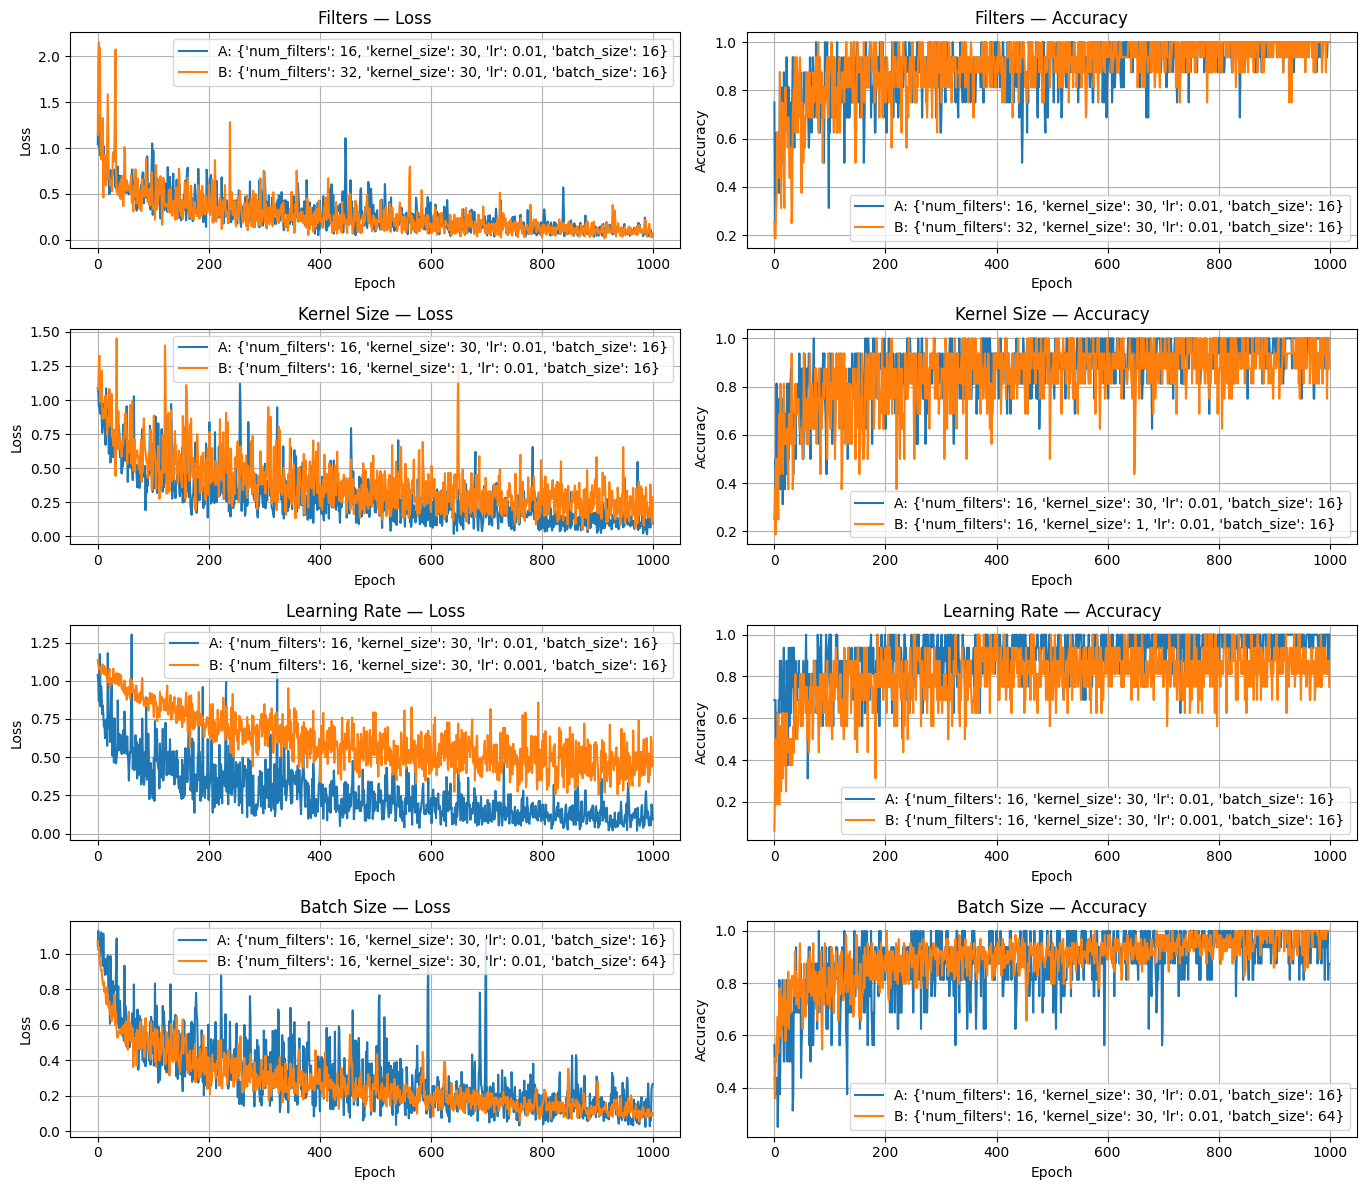

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim

# Define the build_model function
def build_model(input_length, num_filters, kernel_size):
    padding = kernel_size // 2
    # Define layers up to flatten
    layers_before_linear = nn.Sequential(
        nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, padding=padding),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Flatten()
    )

    # Calculate output size after flattening using a dummy input
    dummy_input = torch.randn(1, 1, input_length) # (batch_size, channels, sequence_length)
    with torch.no_grad():
        output_size = layers_before_linear(dummy_input).view(-1).size(0)

    # Combine all layers into the final model
    model = nn.Sequential(
        layers_before_linear,
        nn.Linear(output_size, 3) # Assuming 3 output classes
    )
    return model

# Define the train_cnn function
def train_cnn(model, X_train_tensor, y_train_tensor, lr, batch_size, num_epochs=1000):
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    dataset_size = y_train_tensor.shape[0]
    history = []

    pbar = tqdm(range(num_epochs), desc='Training', leave=True)
    for n in pbar:
        curr_indexes = torch.randint(0, dataset_size, (batch_size,))
        curr_x = X_train_tensor[curr_indexes].unsqueeze(1) # (batch, 1, length)
        curr_y = y_train_tensor[curr_indexes] # (batch,)

        # Add a NaN check for robustness, even if catch22 is not explicitly called here
        if torch.isnan(curr_x).any() or torch.isinf(curr_x).any():
            print(f"Warning: NaN or Inf values detected in input at epoch {n}. Skipping batch.")
            continue

        y_pred = model(curr_x)
        loss = loss_fn(y_pred, curr_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted_classes = torch.argmax(y_pred, dim=1)
        acc = (predicted_classes == curr_y).float().mean().item()

        history.append({
            'epoch': n,
            'loss': loss.item(),
            'acc': acc # Use 'acc' to match DataFrame column name
        })
        pbar.set_description(f"Training loss {loss.item():.4f}, Training accuracy: {acc:.4f}")
        pbar.refresh()
    return history


input_length = len(x_train[0])

experiments = [
    ("Filters", {"num_filters": 16}, {"num_filters": 32}),
    ("Kernel Size", {"kernel_size": 30}, {"kernel_size": 1}),
    ("Learning Rate", {"lr": 0.01}, {"lr": 0.001}),
    ("Batch Size", {"batch_size": 16}, {"batch_size": 64}),
]

plt.figure(figsize=(14, 12))

plot_id = 1

for title, paramsA, paramsB in experiments:
#default values
    base = {"num_filters": 16, "kernel_size": 30, "lr": 0.01, "batch_size": 16}
    configA = base.copy(); configA.update(paramsA)
    configB = base.copy(); configB.update(paramsB)

#model
    modelA = build_model(input_length, configA["num_filters"], configA["kernel_size"])
    modelB = build_model(input_length, configB["num_filters"], configB["kernel_size"])

#training
    histA = train_cnn(modelA, X_train_tensor, y_train_tensor, lr=configA["lr"], batch_size=configA["batch_size"])
    histB = train_cnn(modelB, X_train_tensor, y_train_tensor, lr=configB["lr"], batch_size=configB["batch_size"])

    dfA = pd.DataFrame(histA, columns=["epoch", "loss", "acc"])
    dfB = pd.DataFrame(histB, columns=["epoch", "loss", "acc"])

    # --- Plot Loss ---
    plt.subplot(4, 2, plot_id)
    plt.plot(dfA["epoch"], dfA["loss"], label=f"A: {configA}")
    plt.plot(dfB["epoch"], dfB["loss"], label=f"B: {configB}")
    plt.title(f"{title} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plot_id += 1

    # --- Plot Accuracy ---
    plt.subplot(4, 2, plot_id)
    plt.plot(dfA["epoch"], dfA["acc"], label=f"A: {configA}")
    plt.plot(dfB["epoch"], dfB["acc"], label=f"B: {configB}")
    plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plot_id += 1

plt.tight_layout()
plt.show()

## Part 6: Discussion

This part of the exercise focuses on discussing your results and demonstrating your understanding of the methods and concepts. Please answer the following questions in at most two short paragraphs.

**Questions:**
- Which method did you like the most, and why?
- Based on your experience, which distance measure do you think works best for this task?
- What did you find challenging to understand, and what concepts did you find straightforward?
- What are the pros and cons of each method you tried?

There are no strictly "correct" answers, but your grade will be based on how well you understand and articulate the concepts. Reflect on what you've done, and make sure to explain your reasoning clearly.

**Answer:**
The method I've preffered was the Neural network with CNN. It's the most efficient (by far) and easy to code (if you know how to code with torch).

The best method is CNN because we described at the beggining the differences between the 3 classes by intuitively using its common patterns which is what the CNN is trying to find.

My issue was I never coded with torch, pycatch22 and cmap. So the bulk of my time was triying to understand (with ChatGPT) how those libraries work. When the context is settled (what I have/ what I want/ what tools have I), its gets straitforward (the easier parts for me were part 2 to 3.2 included).

DTW:Pro - Easiest to understand / Con - Time-consuming to code

LinearNN:Pro - Fastest to code / Con - Worst performance

CNN:Pro - Accuracy of 1 after the test / Con - Longest to compute


**The End!**